# Data-Driven Customer Retention Strategy for Interconnect

Customer churn is a major concern for subscription-based companies because losing customers directly impacts long-term revenue. For a telecom provider like Interconnect, retaining existing customers is often more cost-effective than constantly acquiring new ones. Being able to identify customers who are likely to leave before they actually churn allows the company to step in early with discounts, loyalty offers, or service improvements.

Interconnect offers two main services:
* Landline phone service
* Various types of internet service

In addition they also have various upgrade options:
* Device Protection
* Online Security
* Technical Support
* Online Backup
* Streaming TV
* Streaming Movies

The goal of this project is to build a machine learning classification model that predicts whether a customer is likely to churn. By accurately identifying high-risk customers, Interconnect can take proactive steps to improve retention and reduce revenue loss.

The data for this analysis is stored across four separate datasets:
* contract.csv
* personal.csv
* internet.csv
* phone.csv

These datasets will be merged into a single analytical dataset and used to explore patterns in customer behavior. After performing exploratory data analysis and feature engineering, several classification models will be trained and evaluated, with a focus on ROC-AUC.

The final outcome will be a predictive model that can support data-driven retention strategies.

## Data Cleaning and Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
contract = pd.read_csv('contract.csv')
personal = pd.read_csv('personal.csv')
internet = pd.read_csv('internet.csv')
phone = pd.read_csv('phone.csv')

In [3]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [4]:
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [5]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [6]:
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [7]:
data = contract.merge(personal, on='customerID', how='left')\
    .merge(internet, on='customerID', how='left')\
    .merge(phone, on='customerID', how='left')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupport       5517 non-null   object 


In [9]:
data.sample(30)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
4895,1394-SUIUH,2016-06-01,No,Month-to-month,Yes,Electronic check,85.15,3670.5,Female,1,Yes,No,Fiber optic,Yes,Yes,No,Yes,No,No,No
2140,3023-GFLBR,2017-03-01,2019-12-01 00:00:00,Month-to-month,No,Credit card (automatic),86.15,2745.7,Female,0,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Yes
5732,1580-BMCMR,2018-07-01,No,Month-to-month,Yes,Electronic check,87.30,1637.3,Male,1,No,No,Fiber optic,Yes,No,No,No,No,Yes,No
1186,7670-ZBPOQ,2015-04-01,No,One year,Yes,Bank transfer (automatic),61.05,3478.75,Female,0,Yes,No,DSL,Yes,No,No,Yes,No,No,Yes
4179,8224-DWCKX,2019-02-01,No,Month-to-month,Yes,Credit card (automatic),73.30,828.05,Male,1,No,No,Fiber optic,No,No,No,No,No,No,Yes
1273,9681-KYGYB,2016-01-01,No,Month-to-month,Yes,Electronic check,88.20,4159.45,Male,1,Yes,No,Fiber optic,Yes,Yes,Yes,No,No,No,Yes
336,6680-NENYN,2016-05-01,2019-12-01 00:00:00,Two year,Yes,Electronic check,104.60,4759.85,Female,0,No,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes
3352,9124-LHCJQ,2019-10-01,2019-11-01 00:00:00,Month-to-month,Yes,Mailed check,85.45,85.45,Female,0,No,No,Fiber optic,No,No,No,No,No,Yes,Yes
1252,7617-EYGLW,2020-01-01,No,Month-to-month,No,Electronic check,19.45,19.45,Male,0,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
4644,5701-ZIKJE,2019-01-01,No,Month-to-month,Yes,Mailed check,50.55,610.75,Male,0,No,No,DSL,No,No,No,Yes,No,No,No


In [10]:
data['BeginDate'] = pd.to_datetime(data['BeginDate'])
reference_date = pd.to_datetime('2020-02-01')
data['tenure_days'] = (reference_date - data['BeginDate']).dt.days

In [11]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['SeniorCitizen'] = data['SeniorCitizen'].astype(int)

In [12]:
data['churn'] = data['EndDate'].apply(lambda x: 0 if x == 'No' else 1)

In [13]:
data.drop(columns=['EndDate'], inplace=True)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   Type              7043 non-null   object        
 3   PaperlessBilling  7043 non-null   object        
 4   PaymentMethod     7043 non-null   object        
 5   MonthlyCharges    7043 non-null   float64       
 6   TotalCharges      7032 non-null   float64       
 7   gender            7043 non-null   object        
 8   SeniorCitizen     7043 non-null   int64         
 9   Partner           7043 non-null   object        
 10  Dependents        7043 non-null   object        
 11  InternetService   5517 non-null   object        
 12  OnlineSecurity    5517 non-null   object        
 13  OnlineBackup      5517 non-null   object        
 14  DeviceProtection  5517 n

In [15]:
data.isna().sum()

customerID             0
BeginDate              0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges          11
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
tenure_days            0
churn                  0
dtype: int64

In [16]:
data['MultipleLines'].value_counts()

No     3390
Yes    2971
Name: MultipleLines, dtype: int64

In [17]:
data['InternetService'].nunique()

2

In [18]:
data['InternetService'].value_counts()

Fiber optic    3096
DSL            2421
Name: InternetService, dtype: int64

In [19]:
services = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

In [20]:
data[services] = data[services].fillna('No')

In [21]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)

In [22]:
data.isna().sum()

customerID          0
BeginDate           0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
tenure_days         0
churn               0
dtype: int64

In [23]:
data.sample(20)

,customerID,BeginDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,...,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,tenure_days,churn
5790,0980-PVMRC,2016-10-01,Month-to-month,Yes,Electronic check,50.85,2036.55,Female,0,Yes,...,DSL,No,Yes,No,No,Yes,Yes,No,1218,0
1344,0536-BGFMZ,2017-10-01,Month-to-month,No,Mailed check,20.50,563.05,Female,0,Yes,...,No,No,No,No,No,No,No,No,853,0
5844,2905-KFQUV,2019-12-01,Month-to-month,Yes,Credit card (automatic),70.40,154.80,Female,0,Yes,...,Fiber optic,No,No,No,No,No,No,No,62,0
3104,6860-YRJZP,2019-05-01,Month-to-month,Yes,Electronic check,74.05,678.45,Male,1,No,...,Fiber optic,No,No,No,No,No,No,Yes,276,0
5920,9355-NPPFS,2017-12-01,Month-to-month,Yes,Electronic check,78.80,2006.10,Female,1,No,...,Fiber optic,No,No,No,No,No,Yes,No,792,0
4756,9518-IMLHK,2017-07-01,Month-to-month,Yes,Bank transfer (automatic),72.45,2156.25,Male,0,No,...,DSL,Yes,Yes,Yes,Yes,Yes,No,No,945,0
2812,3763-GCZHZ,2014-07-01,One year,Yes,Electronic check,104.05,6890.00,Male,0,Yes,...,Fiber optic,No,Yes,No,Yes,Yes,Yes,Yes,2041,1
6662,6810-VCAEX,2016-03-01,One year,No,Credit card (automatic),39.65,1798.65,Female,0,No,...,DSL,Yes,Yes,No,Yes,No,No,No,1432,0
4528,9688-YGXVR,2016-06-01,Month-to-month,Yes,Credit card (automatic),88.15,3973.20,Female,0,No,...,Fiber optic,No,Yes,Yes,No,Yes,No,No,1340,0
5930,8398-TBIYD,2014-02-01,Two year,Yes,Bank transfer (automatic),84.70,6185.15,Female,0,No,...,Fiber optic,Yes,No,No,Yes,No,No,Yes,2191,0


In [24]:
data.duplicated().sum()

0

# Exploratory Data Analysis

In [25]:
data['churn'].value_counts(normalize=True).mul(100).round(2)

0    73.46
1    26.54
Name: churn, dtype: float64

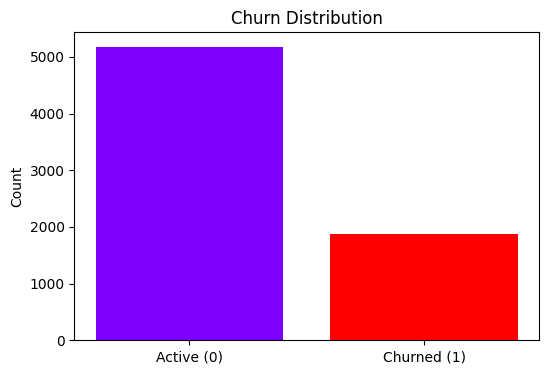

In [26]:
counts = data['churn'].value_counts()
colors = plt.cm.rainbow(np.linspace(0,1,len(counts)))
plt.figure(figsize=(6,4))
plt.bar(['Active (0)', 'Churned (1)'], counts, color=colors)
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.show()

The percentage of customers that churn is 27%, with a retention rate of 73%.

In [27]:
means = data.groupby('churn')[['MonthlyCharges','TotalCharges','tenure_days']].mean()

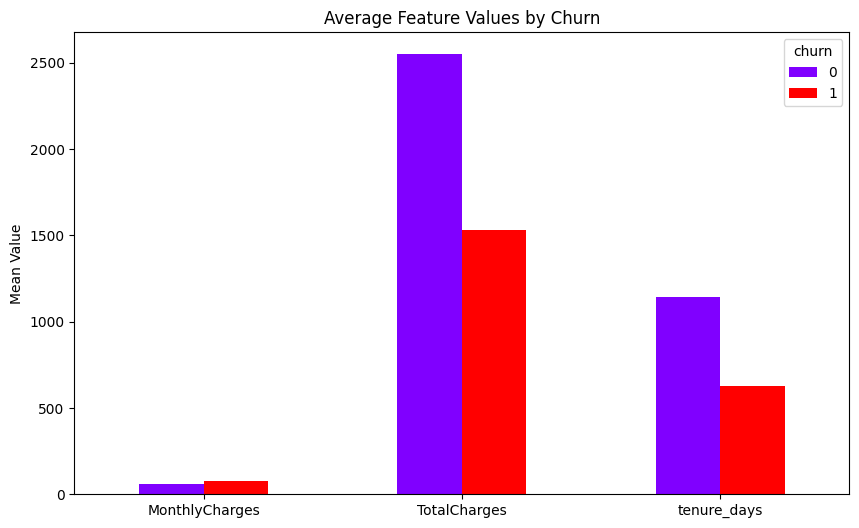

In [28]:
means.T.plot(kind='bar',
             figsize=(10,6),
             colormap='rainbow')

plt.title('Average Feature Values by Churn')
plt.ylabel('Mean Value')
plt.xticks(rotation=0)
plt.show()

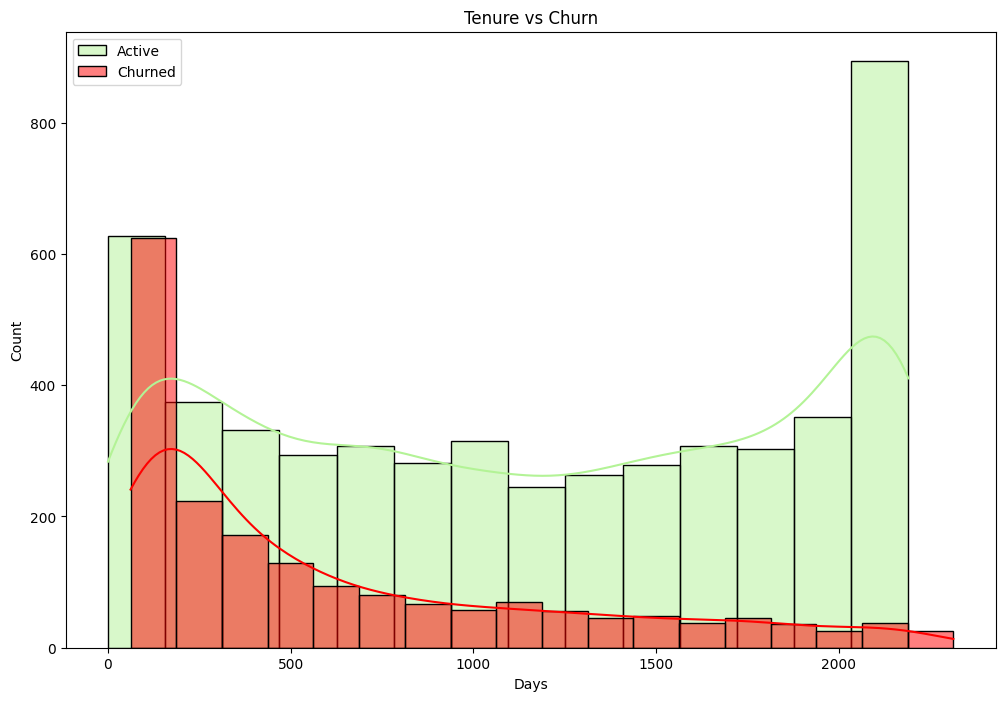

In [29]:
color = plt.cm.rainbow([.6, 1])

plt.figure(figsize=(12,8))

sns.histplot(data=data[data['churn'] == 0],
             x='tenure_days',
             color=color[0],
             kde=True,
             label='Active'
        )
sns.histplot(data=data[data['churn'] == 1],
            x='tenure_days',
             color=color[1],
             kde=True,
             label='Churned'
        )
plt.legend()
plt.title("Tenure vs Churn")
plt.xlabel('Days')
plt.ylabel('Count')
plt.show()

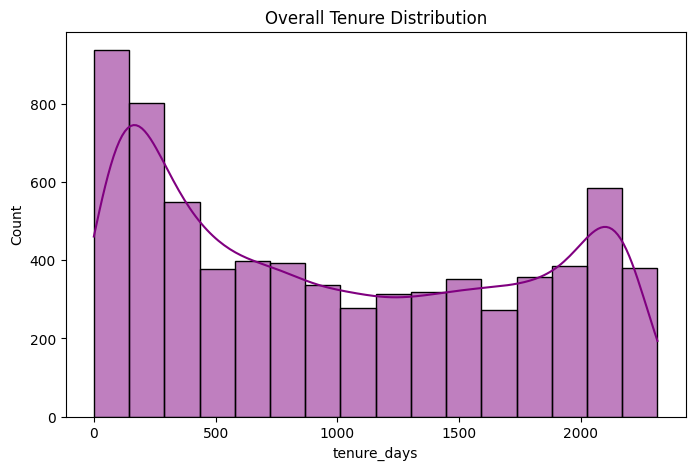

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(data=data, x='tenure_days', color='purple', kde=True)

plt.title('Overall Tenure Distribution')
plt.show()

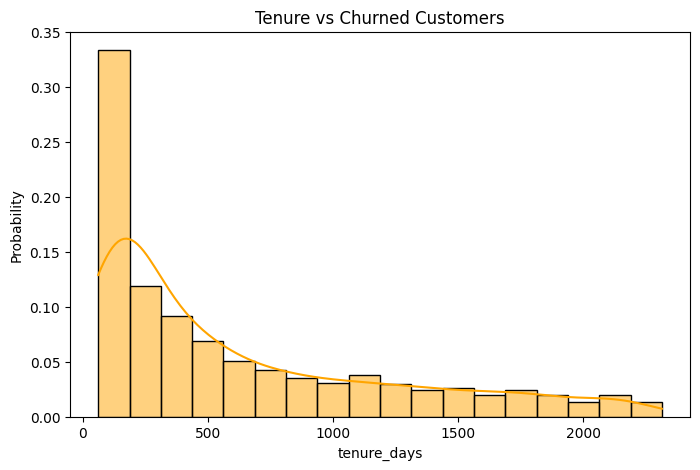

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data[data['churn'] == 1],
    x='tenure_days',
    stat='probability',
    kde=True,
    color='orange'
)

plt.title('Tenure vs Churned Customers')
plt.show()

Customers with shorter tenure are significantly more likely to churn. Long-term customers are much more stable and less likely to leave the service. Customers who churn tend to have significantly shorter tenure and slightly higher monthly charges compared to active customers. There are several factors that could be contributing to the churning of newer customers.
* Customers are still evaluating the service
* Less feelings of 'loyalty'
* Month to month is offered so this allows for clients to leave at anytime
* More price conscientious

## Service Correlations to Tenure

In [33]:
churned = data[data['churn'] == 1]

### Tech Support

In [34]:
churned['TechSupport'].value_counts(normalize=True).mul(100).round(2)

No     83.41
Yes    16.59
Name: TechSupport, dtype: float64

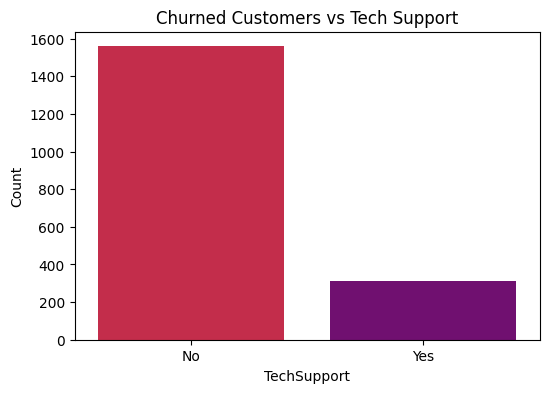

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=churned,
    x='TechSupport',
    palette=['crimson', 'purple']
)

plt.title('Churned Customers vs Tech Support')
plt.ylabel('Count')
plt.show()

In [37]:
pd.crosstab(data['TechSupport'],data['churn'],normalize='index').mul(100).round(2)

churn,0,1
TechSupport,,
No,68.81,31.19
Yes,84.83,15.17


Clients without tech support were roughly twice as likely to churn than those with tech support.

### Internet Services

In [38]:
churned['InternetService'].value_counts(normalize=True).mul(100).round(2)

Fiber optic    69.40
DSL            24.56
No              6.05
Name: InternetService, dtype: float64

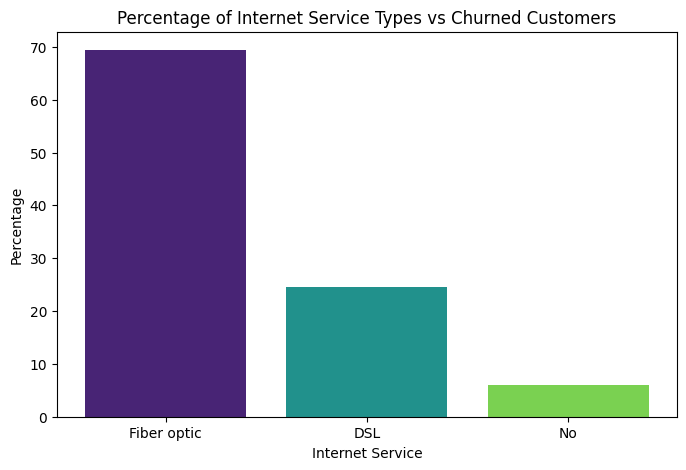

In [39]:
internet_churn = (
    churned['InternetService']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(8,5))

plt.bar(internet_churn.index, internet_churn.values, color=plt.cm.viridis([0.1,0.5,0.8]))

plt.title('Percentage of Internet Service Types vs Churned Customers')
plt.ylabel('Percentage')
plt.xlabel('Internet Service')
plt.show()

In [40]:
pd.crosstab(data['InternetService'],data['churn'],normalize='index').mul(100).round(2)

churn,0,1
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


Clients with internet service through fiber optics have a large churn rate compared to none and DSL services.

### Online Security Services

In [41]:
churned['OnlineSecurity'].value_counts(normalize=True).mul(100).round(2)

No     84.22
Yes    15.78
Name: OnlineSecurity, dtype: float64

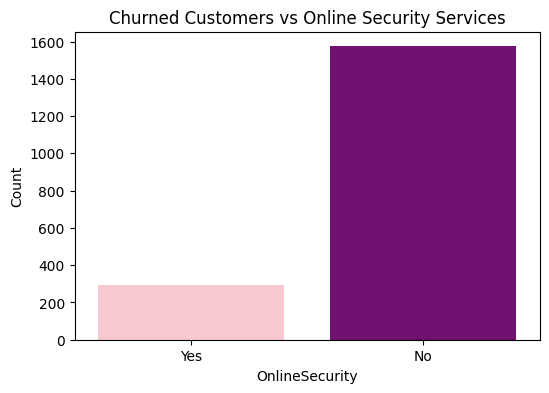

In [45]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=churned,
    x='OnlineSecurity',
    palette=['pink', 'purple']
)

plt.title('Churned Customers vs Online Security Services')
plt.ylabel('Count')
plt.show()

In [46]:
pd.crosstab(data['OnlineSecurity'],data['churn'],normalize='index').mul(100).round(2)

churn,0,1
OnlineSecurity,,
No,68.67,31.33
Yes,85.39,14.61


Clients without online security were roughly twice as likely to churn than those with.

### Contract Type

In [47]:
churned['Type'].value_counts(normalize=True).mul(100).round(2)

Month-to-month    88.55
One year           8.88
Two year           2.57
Name: Type, dtype: float64

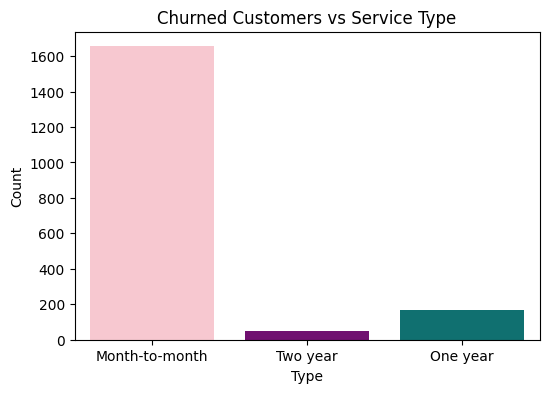

In [50]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=churned,
    x='Type',
    palette=['pink', 'purple', 'teal']
)

plt.title('Churned Customers vs Service Type')
plt.ylabel('Count')
plt.show()

In [51]:
pd.crosstab(data['Type'],data['churn'],normalize='index').mul(100).round(2)

churn,0,1
Type,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


* Clients who choose month to month verses a one year contract are almost 4 times more likes to churn.
* Those clients who go with month to month instead of a two year contract are 15 times more likely to churn.

Offering incentives for going with a 1 or 2 year contract verses a month to month would substantially increase likelihood of client loyalty. 

### Online Backup/ Device Protection

In [52]:
churned['OnlineBackup'].value_counts(normalize=True).mul(100).round(2)

No     72.02
Yes    27.98
Name: OnlineBackup, dtype: float64

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=churned,
    x='OnlineBackup',
    hue='OnlineBackup',
    palette=['pink', 'purple'],
    legend=False
)

plt.title('Churned Customers vs Online Backup Services')
plt.ylabel('Count')
plt.show()

In [ ]:
pd.crosstab(data['OnlineBackup'],data['churn'],normalize='index').mul(100).round(2)

In [ ]:
churned['DeviceProtection'].value_counts(normalize=True).mul(100).round(2)

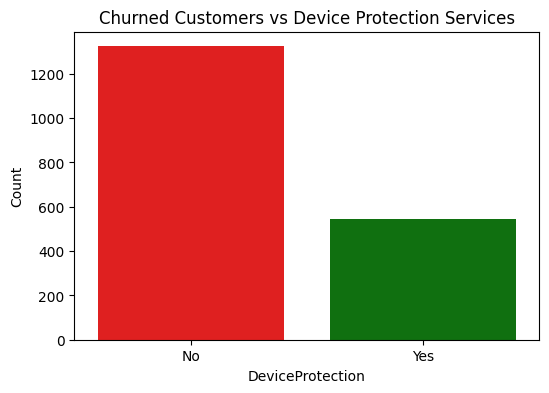

In [53]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=churned,
    x='DeviceProtection',
    palette=['red', 'green']
)

plt.title('Churned Customers vs Device Protection Services')
plt.ylabel('Count')
plt.show()

In [54]:
pd.crosstab(data['DeviceProtection'],data['churn'],normalize='index').mul(100).round(2)

churn,0,1
DeviceProtection,,
No,71.35,28.65
Yes,77.50,22.50


Neither online backup services or device protection services seem to have a substantial effect on churn rates.

### Payment Method

In [55]:
churned['PaymentMethod'].value_counts(normalize=True).mul(100).round(2)

Electronic check             57.30
Mailed check                 16.48
Bank transfer (automatic)    13.80
Credit card (automatic)      12.41
Name: PaymentMethod, dtype: float64

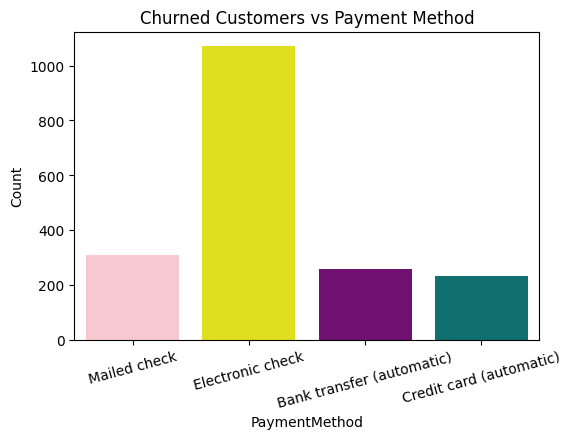

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=churned,
    x='PaymentMethod',
    palette=['pink', 'yellow', 'purple', 'teal'],
)

plt.title('Churned Customers vs Payment Method')
plt.xticks(rotation=15)
plt.ylabel('Count')
plt.show()

In [58]:
pd.crosstab(data['PaymentMethod'],data['churn'],normalize='index').mul(100).round(2)

churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


Electronic checks are highly popular with clients who eventually churn.

## EDA Conclusion

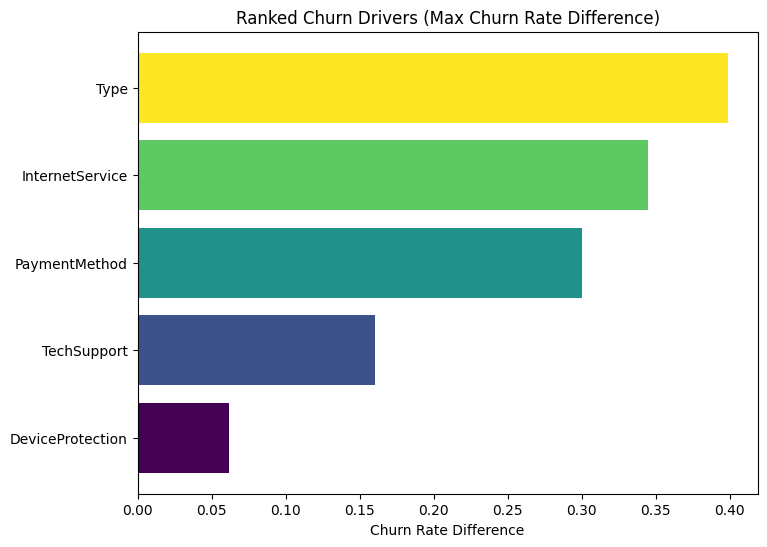

In [59]:
def churn_gap(feature):
    table = pd.crosstab(
        data[feature],
        data['churn'],
        normalize='index'
    )
    return table[1].max() - table[1].min()

features = [
    'Type',
    'PaymentMethod',
    'TechSupport',
    'DeviceProtection',
    'InternetService'
]

gaps = {feature: churn_gap(feature) for feature in features}

gap_df = pd.DataFrame.from_dict(
    gaps,
    orient='index',
    columns=['Churn Rate Gap']
).sort_values('Churn Rate Gap')

plt.figure(figsize=(8,6))

colors = plt.cm.viridis(np.linspace(0,1,len(gap_df)))

plt.barh(gap_df.index, gap_df['Churn Rate Gap'], color=colors)

plt.title('Ranked Churn Drivers (Max Churn Rate Difference)')
plt.xlabel('Churn Rate Difference')
plt.show()

   Exploratory analysis reveals several strong predictors of customer churn. Contract type is the most influential categorical factor, with month to month customers exhibiting a churn rate of 42.71%, nearly 15 times higher than customers on two year contracts (less than 3%). Payment method further differentiates churn risk, with electronic check users displaying a churn rate nearly three times higher than customers using automatic payment methods. Additional service features such as Tech Support and Device Protection are associated with moderate reductions in churn. 
Overall, churn appears to be most strongly linked to:
* contract commitment level
* customer tenure
* payment method

In [60]:
data = data.drop(columns=['customerID'])

In [61]:
features_train, features_valid, target_train, target_valid = train_test_split(
    data.drop('churn', axis=1), data.churn, test_size=0.25, random_state=12345, stratify=data['churn']
)

In [62]:
target_train.mean()

0.2654297614539947

In [63]:
target_valid.mean()

0.26519023282226006

# CatBoostClassifier:

In [64]:
%pip install -q catboost

Note: you may need to restart the kernel to use updated packages.


In [65]:
cat_features = [
    'Type',
    'PaperlessBilling',
    'PaymentMethod',
    'gender',
    'Partner',
    'Dependents',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'MultipleLines',
]

In [66]:
cat_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_seed=12345,
    verbose=100,
    allow_writing_files=False,
    early_stopping_rounds=50 
)

cat_model.fit(
    features_train, 
    target_train, 
    cat_features=cat_features,
    eval_set=(features_valid, target_valid),
    use_best_model=True,
    verbose=20)

probabilities_valid = cat_model.predict_proba(features_valid)[:, 1]
roc_auc = roc_auc_score(target_valid, probabilities_valid)
print('ROC_AUC Score:', roc_auc)

0:	test: 0.8397066	best: 0.8397066 (0)	total: 50.3ms	remaining: 50.3s
20:	test: 0.8672476	best: 0.8672476 (20)	total: 205ms	remaining: 9.57s
40:	test: 0.8794361	best: 0.8794361 (40)	total: 335ms	remaining: 7.84s
60:	test: 0.8860612	best: 0.8860810 (59)	total: 527ms	remaining: 8.11s
80:	test: 0.8891251	best: 0.8893245 (77)	total: 725ms	remaining: 8.22s
100:	test: 0.8928269	best: 0.8928980 (99)	total: 921ms	remaining: 8.2s
120:	test: 0.8953952	best: 0.8955060 (118)	total: 1.11s	remaining: 8.07s
140:	test: 0.8977417	best: 0.8977417 (139)	total: 1.31s	remaining: 7.97s
160:	test: 0.9010215	best: 0.9011357 (159)	total: 1.5s	remaining: 7.84s
180:	test: 0.9046224	best: 0.9046224 (180)	total: 1.7s	remaining: 7.71s
200:	test: 0.9083374	best: 0.9083374 (200)	total: 1.9s	remaining: 7.56s
220:	test: 0.9114692	best: 0.9115064 (218)	total: 2.11s	remaining: 7.43s
240:	test: 0.9144627	best: 0.9144627 (240)	total: 2.31s	remaining: 7.28s
260:	test: 0.9165925	best: 0.9165925 (260)	total: 2.51s	remaining: 

## CatBoost Hyperparameter Tuning

In [67]:
train_pool = Pool(features_train,target_train, cat_features=cat_features)
valid_pool = Pool(features_valid, target_valid, cat_features=cat_features)

In [68]:
param_grid = {
    'depth': [6, 8],
    'learning_rate': [0.03, 0.05],
    'l2_leaf_reg': [3, 5],
    'iterations': [600,1000]
}

tune_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=12345,
    verbose=0,
    early_stopping_rounds=50,
    allow_writing_files=False
)

grid_result = tune_model.grid_search(
    param_grid,
    train_pool,
    cv=3,
    stratified=True,
    shuffle=True,
    partition_random_seed=12345,
    verbose=False
)

best_params = grid_result["params"]
print("Best Parameters:", best_params)
print("Best CV ROC-AUC:", max(grid_result["cv_results"]["test-AUC-mean"]))


bestTest = 0.9301120059
bestIteration = 599

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.9351430158
bestIteration = 599

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.9287559011
bestIteration = 587

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.

bestTest = 0.9353975747
bestIteration = 599

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9366703693
bestIteration = 926

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
Stopped by overfitting detector  (50 iteration

In [69]:
final_model = CatBoostClassifier(
    **best_params,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=12345,
    verbose=100,
    early_stopping_rounds=50,
    allow_writing_files=False
)

final_model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True,
    verbose=20
)

final_pred = final_model.predict_proba(features_valid)[:, 1]
final_auc = roc_auc_score(target_valid, final_pred)

print("Tuned ROC-AUC on validation:", final_auc)

0:	test: 0.8395047	best: 0.8395047 (0)	total: 3.73ms	remaining: 3.73s
20:	test: 0.8667148	best: 0.8669208 (19)	total: 191ms	remaining: 8.9s
40:	test: 0.8782165	best: 0.8782165 (40)	total: 389ms	remaining: 9.09s
60:	test: 0.8825257	best: 0.8825430 (58)	total: 583ms	remaining: 8.98s
80:	test: 0.8858370	best: 0.8858370 (80)	total: 780ms	remaining: 8.85s
100:	test: 0.8896124	best: 0.8896124 (100)	total: 979ms	remaining: 8.71s
120:	test: 0.8925696	best: 0.8925696 (120)	total: 1.1s	remaining: 7.98s
140:	test: 0.8938471	best: 0.8939100 (138)	total: 1.29s	remaining: 7.89s
160:	test: 0.8967248	best: 0.8967248 (160)	total: 1.49s	remaining: 7.76s
180:	test: 0.8992484	best: 0.8992484 (180)	total: 1.68s	remaining: 7.62s
200:	test: 0.9045901	best: 0.9045901 (200)	total: 1.88s	remaining: 7.49s
220:	test: 0.9078948	best: 0.9078948 (220)	total: 2.08s	remaining: 7.33s
240:	test: 0.9110075	best: 0.9110075 (240)	total: 2.28s	remaining: 7.17s
260:	test: 0.9132531	best: 0.9132531 (260)	total: 2.48s	remainin

Using the CatBoost model, a baseline ROC-AUC score of 0.9315 was achieved on the validation set. After performing hyperparameter tuning with 3-fold cross-validation and early stopping, the final model achieved a ROC-AUC of 0.933.

While tuning produced a slight improvement in performance, the gain was marginal relative to the additional computational time required. This indicates that the baseline CatBoost configuration was already near optimal for this dataset. Given the strong and stable performance above 0.93 ROC-AUC, the baseline model was sufficient to meet the project objectives.

In [70]:
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_valid)

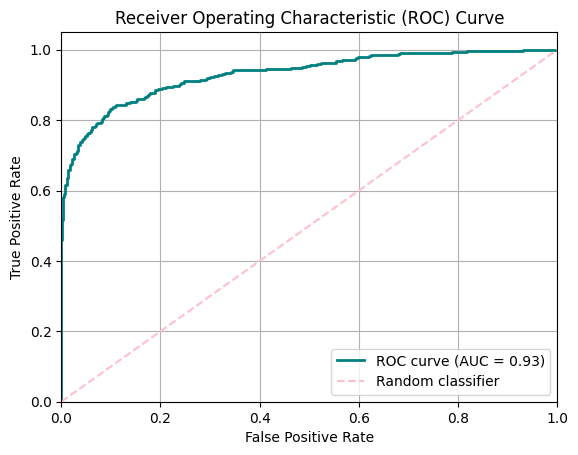

In [71]:
plt.plot(fpr, tpr, 
         color='teal', 
         lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 
         color='pink', 
         linestyle='--', 
         label='Random classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [72]:
importance = pd.DataFrame({
    'Feature': features_train.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

importance.head(5)

,Feature,Importance
5,TotalCharges,28.954685
18,tenure_days,14.767511
0,BeginDate,13.895253
4,MonthlyCharges,13.005515
1,Type,8.427657


# Final Report

The goal of this project was to develop a machine learning model capable of predicting customer churn for Interconnect. By identifying customers at risk of canceling their services, the company can proactively offer targeted retention incentives such as discounts or service upgrades, ultimately reducing revenue loss.

The dataset consisted of over **7,000 customers** and was compiled from four separate tables containing:

* Contract information  
* Demographic data  
* Internet services  
* Phone services  

After merging the datasets, exploratory data analysis was performed on the combined dataset.

### Key Findings from Exploratory Analysis

* Roughly **27%** of customers **churn**
* Monthly **bills** were **higher** for customers who churned
* Customers with service lasting at least **188 days** were **significantly less likely** to churn
* Customers without tech support or online security were **more likely to churn** than those with these services
* Among customers with internet service, those using **fiber optic service** had a **higher churn rate** compared to DSL or no internet service
* Customers on a **month-to-month contract** were nearly **4 times more likely** to churn than those on a one-year contract
* Compared to two-year contracts, month-to-month customers were nearly **15 times more likely** to churn
* Online backup and device protection services did **not** appear to significantly impact churn rates
* **Electronic check payments were strongly associated with churn**, compared to automatic payments or mailed checks


## Modeling Approach

Once exploratory analysis was complete, categorical and numerical features were prepared for modeling. A **CatBoost classification model** was selected due to its ability to efficiently handle categorical variables and its strong performance on structured data.

The dataset was split into training and validation sets, and model performance was evaluated using **ROC-AUC**


## Model Performance

* **Baseline ROC-AUC:** 0.9315  
* **Tuned ROC-AUC:** 0.933  

One of the main challenges encountered during this project was hyperparameter tuning. Expanding the search space significantly increased runtime, and many parameter combinations produced very similar ROC-AUC scores, indicating diminishing returns.

This was addressed by:

* Reducing the hyperparameter search space  
* Using **3-fold cross-validation** instead of 5-fold  
* Applying **early stopping (50 rounds)** to limit unnecessary model training  

After tuning, the final model achieved a ROC-AUC of **0.933**, confirming that the baseline configuration was already near optimal.


## Conclusion

With a ROC-AUC above **0.93**, the final model demonstrates strong ability to distinguish between customers who are likely to churn and those who are not.

This predictive capability allows Interconnect to implement proactive, data-driven retention strategies that can improve long-term revenue and customer stability.